# REGRESSÃO LOGÍSTICA BINÁRIA COM VARIÁVEIS EXPLICATIVAS QUI E QUANT

A Regressão Logística Binária com Variáveis Explicativas Qualitativas e Quantitativas é usada para prever a probabilidade
de um evento ocorrer (ex: fidelidade de clientes) com base em diferentes tipos de variáveis.

Aqui está a explicação em 3 pontos simples:

   1. O Objetivo: Modelar a probabilidade de fidelidade (sim/não) com base em
      variáveis quantitativas (preço) e qualitativas (atendimento, sortimento, acessibilidade).
   2. A Dummização: Variáveis qualitativas são transformadas em variáveis binárias
      para que o modelo possa trabalhar com elas.
   3. A Previsão: Com o modelo final, podemos estimar a probabilidade de fidelidade
      para novos clientes.

   A fórmula básica que você verá no notebook é:
   P(y=1) = 1 / (1 + e^-(α + β₁×preço + β₂×atendimento + β₃×sortimento + β₄×acessibilidade))
    * P: Probabilidade do evento ocorrer.
    * e: Número de Euler (~2.718).
    * α e β: São os números que o modelo aprende para ajustar a curva.

   Em resumo: é transformar dados em uma curva em S para prever probabilidades de eventos com base em múltiplas variáveis.
</markdown_cell>



#### EXEMPLO 3 - Previsão de fidelidade de clientes
</markdown_cell>



1 - Importação dos pacotes
</markdown_cell>



In [8]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import matplotlib.pyplot as plt # visualização gráfica
from scipy.interpolate import UnivariateSpline # curva sigmoide suavizada
import statsmodels.api as sm # estimação de modelos
from statstests.process import stepwise # procedimento Stepwise
from scipy import stats # estatística chi2
import plotly.graph_objects as go # gráficos 3D
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from statsmodels.discrete.discrete_model import MNLogit # estimação do modelo
                                                        #logístico multinomial

import warnings
warnings.filterwarnings("ignore")

2 - Carregando Dados
</markdown_cell>



In [9]:
# CARREGAMENTO DA BASE DE DADOS
df_fidelidade = pd.read_csv('dados_fidelidade.csv', delimiter=',')
df_fidelidade

# Características das variáveis do dataset
df_fidelidade.info()

# Estatísticas univariadas
df_fidelidade.describe()


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              3000 non-null   int64
 1   fidelidade      3000 non-null   str  
 2   sexo            3000 non-null   str  
 3   idade           3000 non-null   int64
 4   atendimento     3000 non-null   int64
 5   sortimento      3000 non-null   int64
 6   acessibilidade  3000 non-null   int64
 7   preço           3000 non-null   int64
dtypes: int64(6), str(2)
memory usage: 187.6 KB


,id,idade,atendimento,sortimento,acessibilidade,preço
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,34.21000,3.490000,3.360000,3.330000,3.380000
std,866.169729,1.57058,0.964474,1.221023,1.296789,1.017814
min,1.000000,29.00000,1.000000,1.000000,1.000000,1.000000
25%,750.750000,34.00000,3.000000,2.750000,3.000000,3.000000
50%,1500.500000,34.00000,4.000000,4.000000,3.000000,3.000000
75%,2250.250000,34.00000,4.000000,4.000000,5.000000,4.000000
max,3000.000000,42.00000,5.000000,5.000000,5.000000,5.000000


2.1 - Transformação dos tipos das variáveis
</markdown_cell>



In [10]:
# Transformação do id para o tipo str
df_fidelidade['id'] = df_fidelidade['id'].astype('str')

# Transformação das variáveis explicativas qualitativas para o tipo object
df_fidelidade['atendimento'] = df_fidelidade['atendimento'].astype('object')
df_fidelidade['sortimento'] = df_fidelidade['sortimento'].astype('object')
df_fidelidade['acessibilidade'] = df_fidelidade['acessibilidade'].astype('object')
df_fidelidade['preço'] = df_fidelidade['preço'].astype('object')

df_fidelidade.info()
df_fidelidade.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              3000 non-null   str   
 1   fidelidade      3000 non-null   str   
 2   sexo            3000 non-null   str   
 3   idade           3000 non-null   int64 
 4   atendimento     3000 non-null   object
 5   sortimento      3000 non-null   object
 6   acessibilidade  3000 non-null   object
 7   preço           3000 non-null   object
dtypes: int64(1), object(4), str(3)
memory usage: 187.6+ KB


,idade
count,3000.00000
mean,34.21000
std,1.57058
min,29.00000
25%,34.00000
50%,34.00000
75%,34.00000
max,42.00000


2.2 - Frequência das variáveis qualitativas
</markdown_cell>



In [11]:
# Tabela de frequências absolutas da variável 'fidelidade'
df_fidelidade['fidelidade'].value_counts().sort_index()

# Tabela de frequências absolutas da variável 'sexo'
df_fidelidade['sexo'].value_counts().sort_index()

# Tabela de frequências absolutas da variável 'atendimento'
df_fidelidade['atendimento'].value_counts().sort_index()

# Tabela de frequências absolutas da variável 'sortimento'
df_fidelidade['sortimento'].value_counts().sort_index()

# Tabela de frequências absolutas da variável 'acessibilidade'
df_fidelidade['acessibilidade'].value_counts().sort_index()

# Tabela de frequências absolutas da variável 'preço'
df_fidelidade['preço'].value_counts().sort_index()

preço
1     180
2     270
3    1170
4     990
5     390
Name: count, dtype: int64

2.3 - Criação da variável dependente binária
</markdown_cell>



In [12]:
# Criação da variável dependente binária "fidelidade"
df_fidelidade['fidelidade'] = df_fidelidade['fidelidade'].astype('object')
df_fidelidade.loc[df_fidelidade['fidelidade']=='sim', 'fidelidade'] = 1
df_fidelidade.loc[df_fidelidade['fidelidade']=='nao', 'fidelidade'] = 0

# Transformando a variável 'fidelidade' para o tipo int
df_fidelidade['fidelidade'] = df_fidelidade['fidelidade'].astype('int64')

df_fidelidade

,id,fidelidade,sexo,idade,atendimento,sortimento,acessibilidade,preço
0,1,0,feminino,34,2,2,1,1
1,2,0,feminino,34,2,2,1,1
2,3,0,masculino,34,3,2,4,2
3,4,0,feminino,34,4,3,3,3
4,5,0,feminino,34,4,3,1,4
...,...,...,...,...,...,...,...,...
2995,2996,1,masculino,34,4,4,1,3
2996,2997,1,feminino,34,4,5,4,2
2997,2998,1,masculino,36,4,4,3,3
2998,2999,1,feminino,35,4,4,5,4


2.4 - Dummização das variáveis explicativas
</markdown_cell>



In [13]:
# Dummização das variáveis explicativas qualitativas
df_fidelidade_dummies = pd.get_dummies(df_fidelidade,
                                       columns=["atendimento",
                                                "sortimento",
                                                "acessibilidade",
                                                "preço",
                                                "sexo"],
                                       dtype=int,
                                       drop_first=True)

df_fidelidade_dummies

,id,fidelidade,idade,atendimento_2,atendimento_3,atendimento_4,atendimento_5,sortimento_2,sortimento_3,sortimento_4,sortimento_5,acessibilidade_2,acessibilidade_3,acessibilidade_4,acessibilidade_5,preço_2,preço_3,preço_4,preço_5,sexo_masculino
0,1,0,34,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2,0,34,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,3,0,34,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1
3,4,0,34,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0
4,5,0,34,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,1,34,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1
2996,2997,1,34,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0
2997,2998,1,36,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1
2998,2999,1,35,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0


3 - Estimação do modelo logístico binário
</markdown_cell>



In [14]:
# Sugestão de uso deste caso, dada a existência de muitas dummies no dataframe
# Definição da fórmula utilizada no modelo

lista_colunas = list(df_fidelidade_dummies.drop(columns=["id",
                                                         "fidelidade"]).columns)
formula_dummies_modelo = " + ".join(lista_colunas)
formula_dummies_modelo = "fidelidade ~ " + formula_dummies_modelo
print("Fórmula utilizada: ", formula_dummies_modelo)

# Modelo propriamente dito
modelo_fidelidade = sm.Logit.from_formula(formula_dummies_modelo,
                                           df_fidelidade_dummies).fit()

# Parâmetros do "modelo_fidelidade"
modelo_fidelidade.summary()

Fórmula utilizada:  fidelidade ~ idade + atendimento_2 + atendimento_3 + atendimento_4 + atendimento_5 + sortimento_2 + sortimento_3 + sortimento_4 + sortimento_5 + acessibilidade_2 + acessibilidade_3 + acessibilidade_4 + acessibilidade_5 + preço_2 + preço_3 + preço_4 + preço_5 + sexo_masculino
Optimization terminated successfully.
         Current function value: 0.257856
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             fidelidade   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2981
Method:                           MLE   Df Model:                           18
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.6241
Time:                        22:37:28   Log-Likelihood:                -773.57
converged:                       True   LL-Null:                       -2057.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -68.9866      6.055    -11.394      0.000     -80.854     -57.120
idade                1.6870      0.176      9.561      0.000       1.341       2.033
atendimento_2        1.6808      0.336      5.004      0.000       1.023       2.339
atendimento_3        1.8172      0.342      5.321      0.000       1.148       2.487
atendimento_4        3.3168      0.311     10.651      0.000       2.706       3.927
atendimento_5        4.3119      0.432      9.977      0.000       3.465       5.159
sortimento_2         1.8503      0.396      4.671      0.000       1.074       2.627
sortimento_3         2.0511      0.321      6.389      0.000       1.422       2.680
sortimento_4         3.3290      0.320     10.388      0.000       2.701       3.957
sortimento_5         5.9365      0.402     14.755      0.000       5.148       6.725
acessibilidade_2     2.3475      0.446      5.258      0.000       1.473       3.223
acessibilidade_3     2.9229      0.281     10.404      0.000       2.372       3.474
acessibilidade_4     4.2907      2.123      2.021      0.043       0.130       8.451
acessibilidade_5     5.3662      0.376     14.260      0.000       4.629       6.104
preço_2              0.5706      2.122      0.269      0.788      -3.589       4.730
preço_3              2.9216      0.390      7.486      0.000       2.157       3.687
preço_4              3.0393      0.416      7.314      0.000       2.225       3.854
preço_5              3.9142      0.442      8.849      0.000       3.047       4.781
sexo_masculino       1.7695      0.197      8.962      0.000       1.383       2.157
====================================================================================
"""

4 - Observação dos parâmetros resultantes da estimação
</markdown_cell>



In [15]:
print(modelo_fidelidade.summary())

                           Logit Regression Results                           
Dep. Variable:             fidelidade   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2981
Method:                           MLE   Df Model:                           18
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.6241
Time:                        22:37:28   Log-Likelihood:                -773.57
converged:                       True   LL-Null:                       -2057.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -68.9866      6.055    -11.394      0.000     -80.854     -57.120
idade                1.6870      0.176      9.561      0.000       1.341       2.033
atendimento_2        1.6808 

5 - Procedimento Stepwise
</markdown_cell>



In [16]:
# Carregamento da função "stepwise" do pacote "statstests.process"
# Autores do pacote: Luiz Paulo Fávero e Helder Prado Santos
# https://stats-tests.github.io/statstests/

from statstests.process import stepwise

# Estimação do modelo por meio do procedimento Stepwise
step_modelo_fidelidade = stepwise(modelo_fidelidade, pvalue_limit=0.05)

print(step_modelo_fidelidade.summary())

Regression type: Logit 

Estimating model...: 
 fidelidade ~ Q('idade') + Q('atendimento_2') + Q('atendimento_3') + Q('atendimento_4') + Q('atendimento_5') + Q('sortimento_2') + Q('sortimento_3') + Q('sortimento_4') + Q('sortimento_5') + Q('acessibilidade_2') + Q('acessibilidade_3') + Q('acessibilidade_4') + Q('acessibilidade_5') + Q('preço_2') + Q('preço_3') + Q('preço_4') + Q('preço_5') + Q('sexo_masculino')
Optimization terminated successfully.
         Current function value: 0.257856
         Iterations 9

 Discarding atribute "Q('preço_2')" with p-value equal to 0.788057057780583 

Estimating model...: 
 fidelidade ~ Q('idade') + Q('atendimento_2') + Q('atendimento_3') + Q('atendimento_4') + Q('atendimento_5') + Q('sortimento_2') + Q('sortimento_3') + Q('sortimento_4') + Q('sortimento_5') + Q('acessibilidade_2') + Q('acessibilidade_3') + Q('acessibilidade_4') + Q('acessibilidade_5') + Q('preço_3') + Q('preço_4') + Q('preço_5') + Q('sexo_masculino')
Optimization terminated success

# Análise da Regressão Logística Binária com Variáveis Qual e Quant

## Resumo do Modelo

O objetivo deste modelo é prever a probabilidade de fidelidade de clientes
com base em variáveis quantitativas (preço) e qualitativas (atendimento, sortimento, acessibilidade, sexo).
As variáveis qualitativas são dummizadas para que o modelo possa trabalhar com elas.
O procedimento Stepwise é utilizado para selecionar automaticamente as variáveis mais relevantes.

### Equação Logística

[
P(fidelidade=1) = 1 / (1 + e^-(α + β₁×preço + β₂×atendimento + β₃×sortimento + β₄×acessibilidade))
]

Onde:

* **Intercepto (α):** Valor base quando as variáveis explicativas são zero.
* **Coeficiente da Preço (β₁):** Impacto do preço na probabilidade de fidelidade.
* **Coeficiente do Atendimento (β₂):** Impacto do atendimento na probabilidade de fidelidade.
* **Coeficiente do Sortimento (β₃):** Impacto do sortimento na probabilidade de fidelidade.
* **Coeficiente da Acessibilidade (β₄):** Impacto da acessibilidade na probabilidade de fidelidade.

---

# Interpretação dos Coeficientes

Os coeficientes da regressão logística estão em log-odds (logit). Para interpretar como probabilidades,
precisamos converter para odds usando e^β e depois para probabilidades.

---

# Dummização das Variáveis Qualitativas

Variáveis qualitativas como "atendimento", "sortimento", "acessibilidade", "preço" e "sexo" são transformadas
em variáveis binárias usando o método one-hot encoding. A opção de drop_first=True é usada para evitar o problema
da multicolinearidade perfeita.

---

# Qualidade do Ajuste

## Log-Likelihood

O log-likelihood mede a probabilidade dos dados dado o modelo. Valores mais próximos de zero indicam melhor ajuste.

## Pseudo R² (McFadden)

Diferente do R² da regressão linear, o pseudo R² da regressão logística mede a melhora do modelo em relação ao modelo nulo (sem variáveis).

---

# Significância do Modelo

## Teste Likelihood Ratio

O teste LR compara o modelo com e sem as variáveis explicativas. Um p-valor baixo indica que as variáveis contribuem significativamente para o modelo.

---

# Seleção de Variáveis com Stepwise

O Stepwise testa diferentes combinações de variáveis e mantém apenas aquelas que contribuem
significativamente para o modelo, usando o critério de p-valor definido pelo usuário.

---

# Previsões com o Modelo Final

## Probabilidades previstas para o dataset



In [18]:
df_fidelidade_dummies['phat'] = step_modelo_fidelidade.predict()
df_fidelidade_dummies

,id,fidelidade,idade,atendimento_2,atendimento_3,atendimento_4,atendimento_5,sortimento_2,sortimento_3,sortimento_4,...,acessibilidade_2,acessibilidade_3,acessibilidade_4,acessibilidade_5,preço_2,preço_3,preço_4,preço_5,sexo_masculino,phat
0,1,0,34,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.000307
1,2,0,34,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.000307
2,3,0,34,0,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0.208086
3,4,0,34,0,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0.398124
4,5,0,34,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0.038641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,1,34,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0.428042
2996,2997,1,34,0,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0.923038
2997,2998,1,36,0,0,1,0,0,0,1,...,0,1,0,0,0,1,0,0,1,0.997545
2998,2999,1,35,0,0,1,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0.994022


## Construção da matriz de confusão



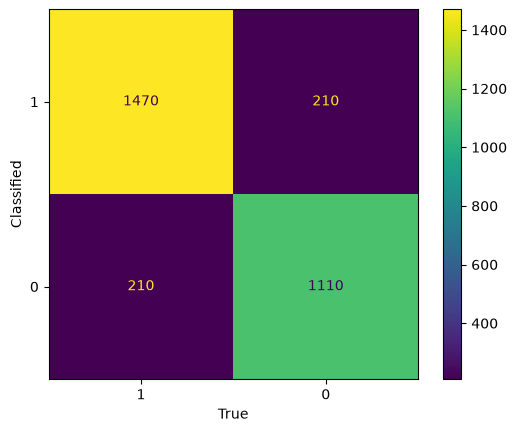

,Sensitividade,Especificidade,Acurácia
0,0.875,0.840909,0.86


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, recall_score

def matriz_confusao(predicts, observado, cutoff):
    values = predicts.values
    predicao_binaria = []
    for item in values:
        if item < cutoff:
            predicao_binaria.append(0)
        else:
            predicao_binaria.append(1)
    cm = confusion_matrix(predicao_binaria, observado)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.xlabel("True")
    plt.ylabel("Classified")
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.show()
    sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
    especificidade = recall_score(observado, predicao_binaria, pos_label=0)
    acuracia = accuracy_score(observado, predicao_binaria)
    indicadores = pd.DataFrame({"Sensitividade":[sensitividade],
                                "Especificidade":[especificidade],
                                "Acurácia":[acuracia]})
    return indicadores

matriz_confusao(observado=df_fidelidade_dummies["fidelidade"],
                predicts=df_fidelidade_dummies["phat"],
                cutoff=0.50)

## Igualando critérios de especificidade e de sensitividade



In [20]:
def espec_sens(observado, predicts):
    values = predicts.values
    cutoffs = np.arange(0, 1.01, 0.01)
    lista_sensitividade = []
    lista_especificidade = []
    for cutoff in cutoffs:
        predicao_binaria = []
        for item in values:
            if item >= cutoff:
                predicao_binaria.append(1)
            else:
                predicao_binaria.append(0)
        sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
        especificidade = recall_score(observado, predicao_binaria, pos_label=0)
        lista_sensitividade.append(sensitividade)
        lista_especificidade.append(especificidade)
    resultado = pd.DataFrame({"cutoffs":cutoffs,"sensitividade":lista_sensitividade,"especificidade":lista_especificidade})
    return resultado

dados_plotagem = espec_sens(observado=df_fidelidade_dummies["fidelidade"],
                            predicts=df_fidelidade_dummies["phat"])
dados_plotagem

,cutoffs,sensitividade,especificidade
0,0.00,1.000000,0.000000
1,0.01,1.000000,0.295455
2,0.02,1.000000,0.318182
3,0.03,1.000000,0.340909
4,0.04,1.000000,0.386364
...,...,...,...
96,0.96,0.625000,1.000000
97,0.97,0.517857,1.000000
98,0.98,0.428571,1.000000
99,0.99,0.339286,1.000000


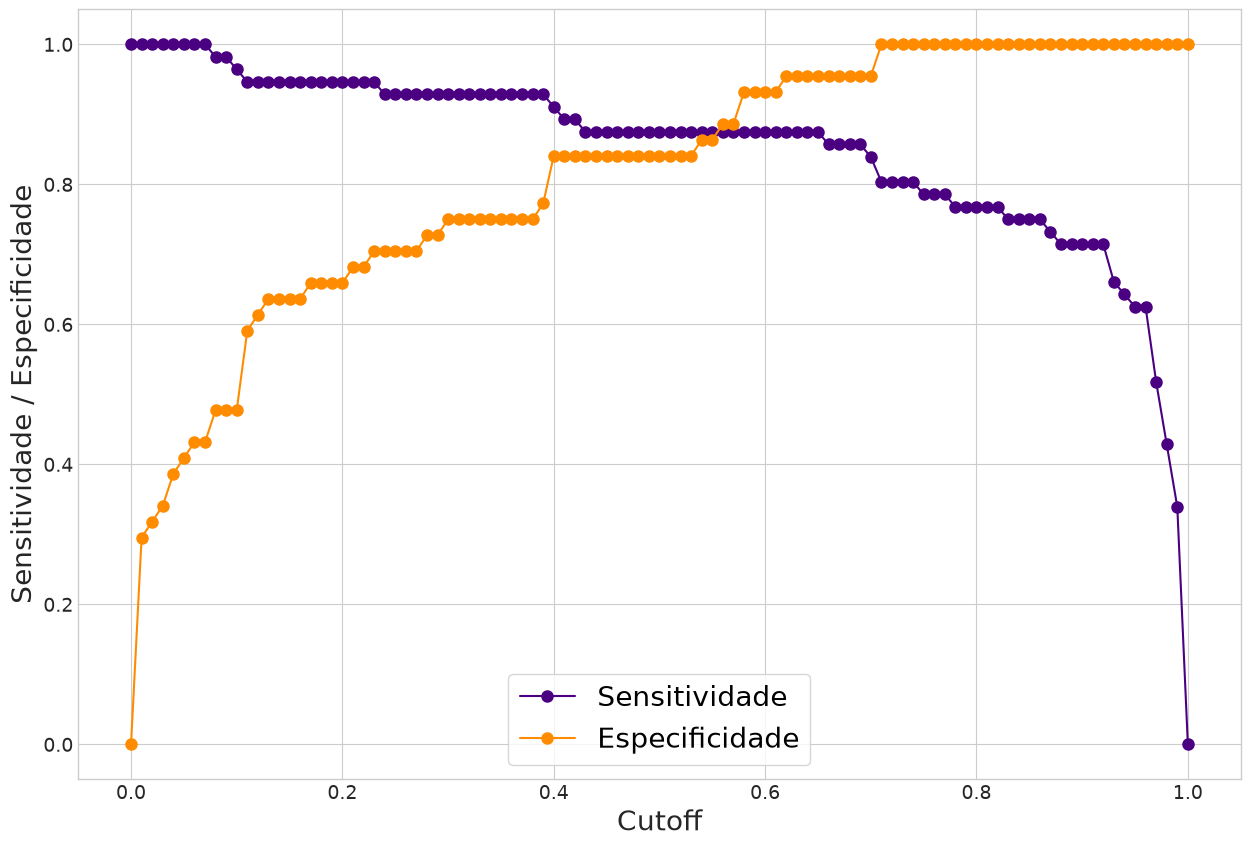

In [21]:
plt.figure(figsize=(15,10))
with plt.style.context("seaborn-v0_8-whitegrid"):
    plt.plot(dados_plotagem.cutoffs, dados_plotagem.sensitividade, marker="o", color="indigo", markersize=8)
    plt.plot(dados_plotagem.cutoffs, dados_plotagem.especificidade, marker="o", color="darkorange", markersize=8)
plt.xlabel("Cutoff", fontsize=20)
plt.ylabel("Sensitividade / Especificidade", fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.legend(["Sensitividade", "Especificidade"], fontsize=20)
plt.show()

## Construção da curva ROC



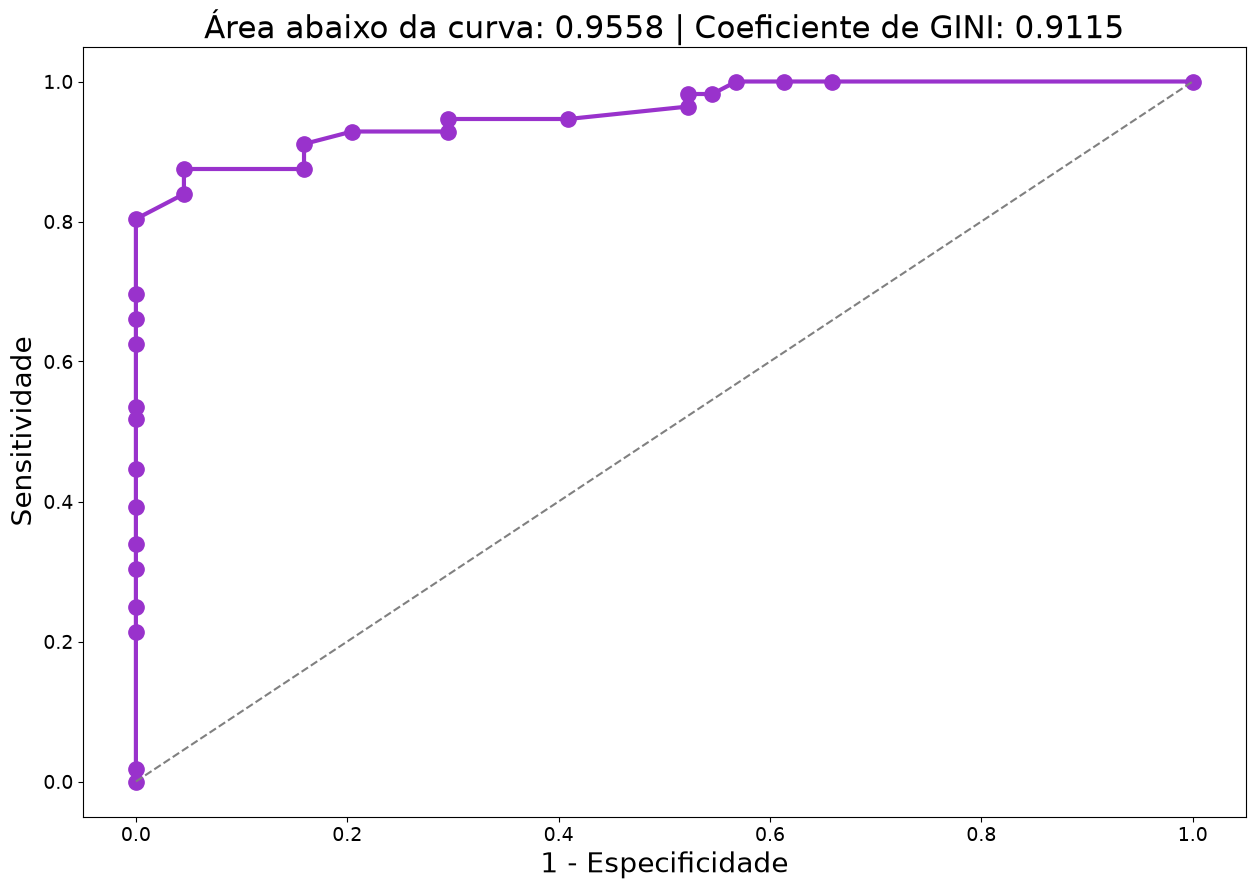

In [22]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(df_fidelidade_dummies["fidelidade"],
                                 df_fidelidade_dummies["phat"])
roc_auc = auc(fpr, tpr)
gini = (roc_auc - 0.5) / 0.5

plt.figure(figsize=(15,10))
plt.plot(fpr, tpr, marker="o", color="darkorchid", markersize=11, linewidth=3)
plt.plot(fpr, fpr, color="gray", linestyle="dashed")
plt.title("Área abaixo da curva: %g" % round(roc_auc, 4) + " | Coeficiente de GINI: %g" % round(gini, 4), fontsize=22)
plt.xlabel("1 - Especificidade", fontsize=20)
plt.ylabel("Sensitividade", fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()

# Resumo: Regressão Logística Binária com Variáveis Qual e Quant

Este documento apresenta um resumo do fluxo de código do notebook, focado na análise da relação entre
**Fidelidade**, **Preço**, **Atendimento**, **Sortimento**, **Acessibilidade** e **Sexo**.

---

## 1. Preparação e Exploração
- **Objetivo:** Prever a probabilidade de fidelidade de clientes com base em diferentes tipos de variáveis.
- **Dados:** O arquivo `dados_fidelidade.csv` é carregado.
- **Análise Inicial:** Uso de `describe()` para estatísticas descritivas e `info()` para verificar tipos de dados.

## 2. Transformação dos Dados
- A variável dependente "fidelidade" é transformada de categórica (sim/nao) para binária (1/0).
- Variáveis explicativas qualitativas são dummizadas usando o método one-hot encoding.

## 3. Visualização Inicial
- É gerado um gráfico pairplot com scatters e KDEs por fidelidade.
- Isso permite visualizar rapidamente as relações entre as variáveis.

## 4. Construção do Modelo
O modelo de **Logística Binária** é estimado:
```python
modelo_fidelidade = sm.Logit.from_formula(formula_dummies_modelo, df_fidelidade_dummies).fit()
```
- A fórmula indica que a fidelidade depende das variáveis dummizadas.
- O `fit()` faz o computador encontrar os melhores números para a curva logística.

## 5. Seleção Stepwise
- O Stepwise seleciona automaticamente as variáveis mais relevantes para o modelo final.
- O critério utilizado é o p-valor, com limite de 0,05.

## 6. Interpretação dos Resultados
Ao rodar `step_modelo_fidelidade.summary()`, obtemos:
- **Coeficientes:** Indicam como cada variável dummizada afeta o log-odds de fidelidade.
- **P-value:** Como é menor que 0,05, a variável é estatisticamente significativa para prever a fidelidade.

## 7. Previsões e Métricas
O código salva os resultados individuais no DataFrame:
- **phat:** A probabilidade prevista de fidelidade para cada observação.
- **Matriz de confusão:** Mede os acertos e erros do modelo com cutoff de 0,5.
- **Curva ROC / AUC:** Mede a capacidade do modelo de separar clientes fiéis de não fiéis.

---
**Conclusão do Notebook:** O modelo logístico com dummização e Stepwise é utilizado para prever a probabilidade de fidelidade de clientes com base nas variáveis mais relevantes.
</markdown_cell>
